# TME ML Non supervisé

In [1]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

tab20 = plt.get_cmap("tab20")


# K-Means et clustering Géographique

## 1- Data preparation

<div class="alert alert-block alert-info">
Pour cette partie, nous allons reprendre les données des points d'intérêts (POI) de Paris. L'objectif est de caractériser spatialement l'espace urbain parisien en fonction des POIs présents dans une région. Le clustering des régions permet ainsi de mettre en évidence les régions similaires et les raisons de leur similarité (en analysant le prototype de chaque cluster).
    
Les lignes suivantes permettent de dessiner les arrondissements parisien à partir du fichier <code>districts-paris.csv</code> et le charger les POIs (fichier <code>poi-paris.csv</code>)
</div>

In [2]:
table_poi = pd.read_csv('data/poi-paris.csv')
districts = pd.read_csv('data/districts-paris.csv', sep=',')
districts['bounds'] = districts['bounds'].apply(eval)

# Types de POIs utilisés pour décrire les régions
types = [
    'furniture_store', 'laundry', 'bakery', 'cafe', 'home_goods_store',
    'clothing_store', 'atm', 'lodging', 'night_club', 'convenience_store',
    'restaurant', 'bar'
]

# Trace les arrondissements de Paris
def draw_districts():
    for x in districts['bounds']:
        plt.plot([c[0] for c in x], [c[1] for c in x], color='black', linewidth=0.8)

print('Nombre total de POIs :', len(table_poi))
print('Types utilisés :', ', '.join(types))


Nombre total de POIs : 31852
Types utilisés : furniture_store, laundry, bakery, cafe, home_goods_store, clothing_store, atm, lodging, night_club, convenience_store, restaurant, bar


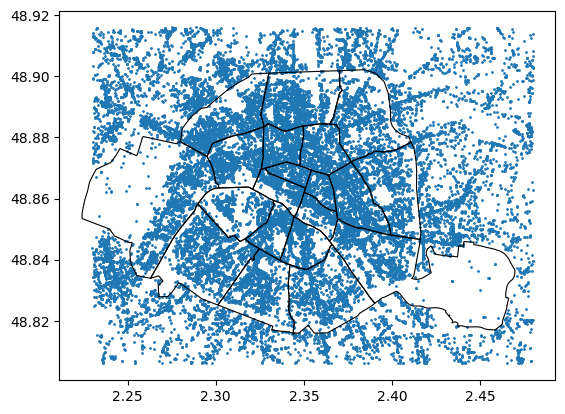

In [3]:
plt.scatter(table_poi["longitude"],table_poi['latitude'],s=1)
draw_districts()

### 2 - Discrétisation manuelle de l'espace

<div class="alert alert-block alert-info">
On ne peut pas utiliser la discrétisation naturelle des arrondissements car celle-ci est trop grande et regroupe des sous-régions de type très différent. Une première façon d'obtenir des sous-régions intéressantes dans Paris est de faire une discrétisation en grille, manuelle. On supposera la grille régulière de taille $N$.

On a donc besoin de connaître pour une coordonnée GPS $(long,lat)$ quelle est la cellule $(i,j)$ de la grille correspondante. Pour une grille de taille $N\times N$, la formule est la suivante : $i=\lfloor N*\frac{(longitude-lomin)}{(lomax-lomin)}\rfloor$ and $j = \lfloor N*\frac{(latitude - lamin)}{(lamax-lamin)} \rfloor$ , avec $\lfloor x\rfloor$ la partie entière de $x$, $lamin,lamax$ les latitudes minimale et maximale, $lomin,lomax$ les longitudes  minimales et maximales.

Chaque cellule de la grille sera décrite par la distribution des types des POIs présents dans l'espace correspondant à la cellule. Il y a 12 types de POIs, ainsi chaque cellule est décrit par un vecteur de dimension 12, donc chaque dimension indique la probabilité du type associé à la dimension dans la région. 
    
Calculez la description associée à chaque cellule. 

Executez un k-means dessus (en utilisant <code>KMeans</code> de scikit-learn, <code>n_clusters</code> permet de fixer le nombre de cluster, la méthode <code>fit()</code> permet de réaliser le clustering, la méthode <code>predict()</code> d'obtenir le cluster associé à chaque exemple, la méthode <code>fit_predict()</code> de faire les deux en même temps).

Visualisez également les centroïdes des clusters. Faites varier le nombre de clusters et comparez les résultats.

Le code suivant permet de représenter graphiquement le clustering calculé (avec <code>get_clust(i,j)</code> renvoyant le numéro du cluster associé à la cellule $(i,j)$) et de tracer les centroïdes (d'un KMeans stocké dans la variable <code>km</code>).


Taille de la grille : 20 x 20
Nombre total de cellules : 400
Nombre de cellules non vides : 392
Proportion de cellules non vides : 0.98
K retenu pour la grille : 6
Inertie du KMeans : 16.0379

Types dominants des clusters de grille :
cluster 0 : home_goods_store (0.368), restaurant (0.259), furniture_store (0.250)
cluster 1 : clothing_store (0.470), restaurant (0.204), home_goods_store (0.098)
cluster 2 : restaurant (0.239), lodging (0.182), home_goods_store (0.157)
cluster 3 : restaurant (0.967), cafe (0.100), bar (0.083)
cluster 4 : restaurant (0.532), bar (0.180), lodging (0.121)
cluster 5 : restaurant (0.363), bar (0.205), lodging (0.134)


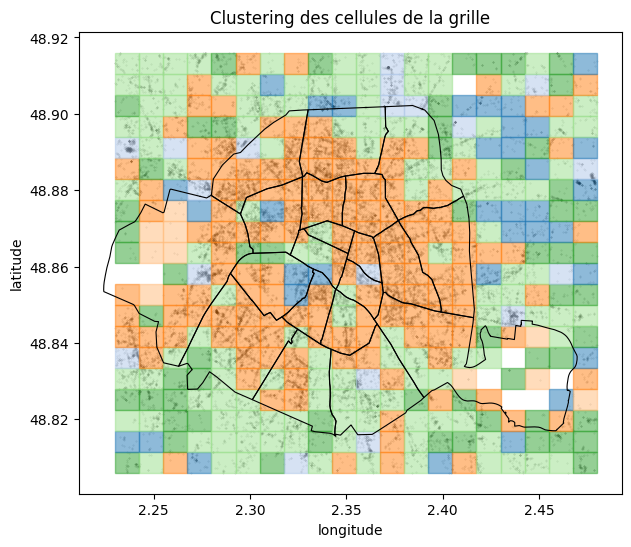

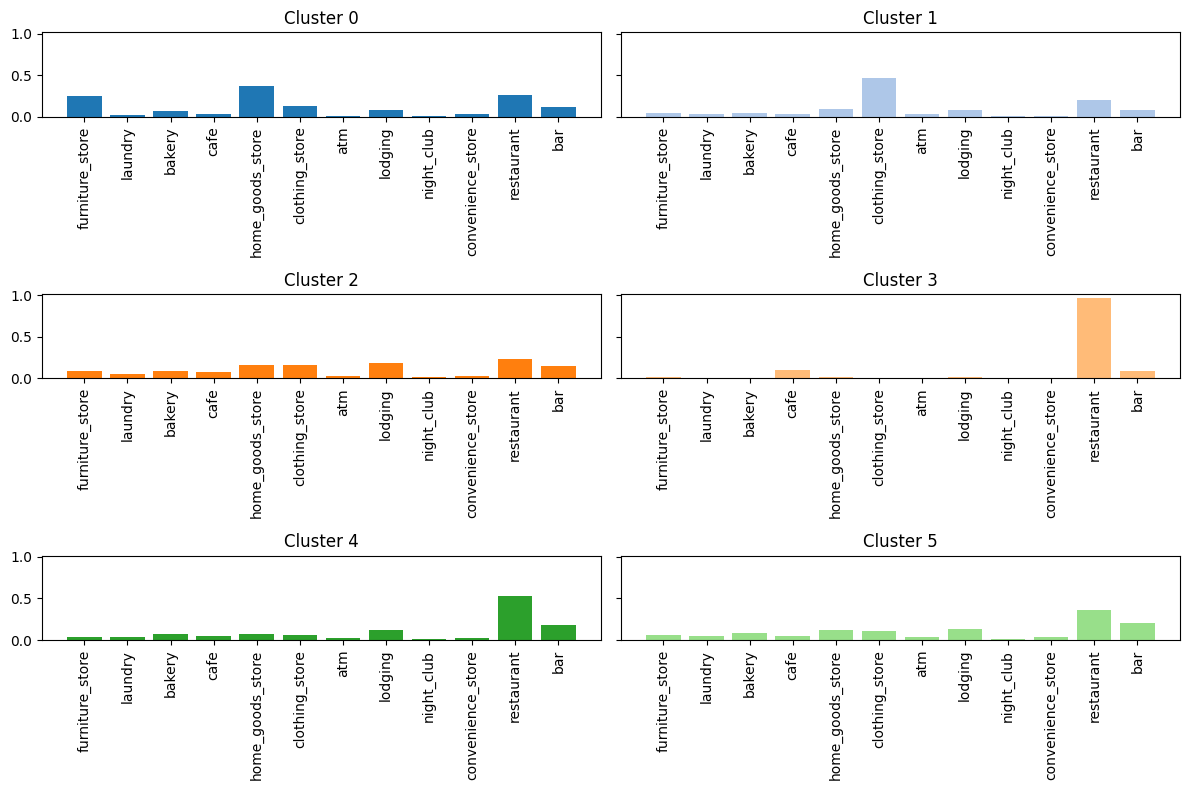

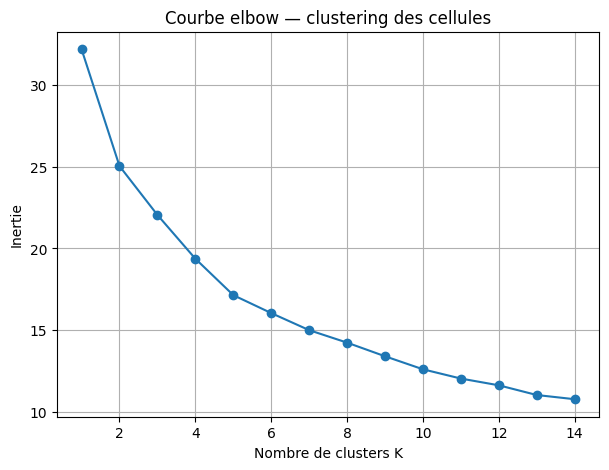


Valeurs de l'inertie :
K= 1 | inertie=32.2017
K= 2 | inertie=25.0436
K= 3 | inertie=22.0497
K= 4 | inertie=19.3680
K= 5 | inertie=17.1376
K= 6 | inertie=16.0379
K= 7 | inertie=14.9922
K= 8 | inertie=14.2279
K= 9 | inertie=13.3928
K=10 | inertie=12.5949
K=11 | inertie=12.0274
K=12 | inertie=11.6143
K=13 | inertie=11.0194
K=14 | inertie=10.7625

Interprétation : le coude n'est pas parfaitement net, mais K=5 ou K=6 semble raisonnable.


In [ ]:
# Discrétisation en grille et clustering des cellules

# Paramètres
N = 20          # taille de la grille N x N
K_GRID = 6     # nombre de clusters choisi pour la visualisation

# Bornes de Paris dans les données
lomin, lomax = table_poi["longitude"].min(), table_poi["longitude"].max()
lamin, lamax = table_poi["latitude"].min(), table_poi["latitude"].max()

def coord_to_cell(longitude, latitude, N):
    """Associe une coordonnée GPS à une cellule (i,j) de la grille."""
    i = np.floor(N * (longitude - lomin) / (lomax - lomin)).astype(int)
    j = np.floor(N * (latitude - lamin) / (lamax - lamin)).astype(int)

    # On évite les indices hors grille pour les points exactement sur le bord.
    i = np.clip(i, 0, N - 1)
    j = np.clip(j, 0, N - 1)

    return i, j


# 1. Description des cellules


# Chaque cellule est décrite par la distribution des 12 types de POIs.
nb_types = len(types)
descriptions = np.zeros((N, N, nb_types))
nb_pois_cellule = np.zeros((N, N))

cell_i, cell_j = coord_to_cell(
    table_poi["longitude"].values,
    table_poi["latitude"].values,
    N
)

for p in range(len(table_poi)):
    i = cell_i[p]
    j = cell_j[p]
    descriptions[i, j, :] += table_poi.iloc[p][types].astype(float).values
    nb_pois_cellule[i, j] += 1

# On transforme les comptes en proportions dans chaque cellule.
for i in range(N):
    for j in range(N):
        if nb_pois_cellule[i, j] > 0:
            descriptions[i, j, :] /= nb_pois_cellule[i, j]

# On ne garde que les cellules non vides pour le clustering.
X_grid = descriptions.reshape(N * N, nb_types)
mask_grid = nb_pois_cellule.reshape(-1) > 0


# 2. KMeans sur les cellules de la grille


km = KMeans(n_clusters=K_GRID, random_state=0, n_init=10)
labels_non_vides = km.fit_predict(X_grid[mask_grid])

labels_grid_flat = -np.ones(N * N, dtype=int)
labels_grid_flat[mask_grid] = labels_non_vides
labels_grid = labels_grid_flat.reshape(N, N)

def get_clust(i, j):
    """Renvoie le cluster de la cellule (i,j), ou -1 si elle est vide."""
    return labels_grid[i, j]

print("Taille de la grille :", N, "x", N)
print("Nombre total de cellules :", N * N)
print("Nombre de cellules non vides :", int(mask_grid.sum()))
print("Proportion de cellules non vides :", round(mask_grid.mean(), 3))
print("K retenu pour la grille :", K_GRID)
print("Inertie du KMeans :", round(km.inertia_, 4))

print("\nTypes dominants des clusters de grille :")
for k, center in enumerate(km.cluster_centers_):
    order = np.argsort(center)[::-1][:3]
    top = ", ".join([f"{types[i]} ({center[i]:.3f})" for i in order])
    print(f"cluster {k} : {top}")


# 3. Visualisation du clustering des cellules


plt.figure(figsize=(7, 6))
plt.scatter(table_poi["longitude"], table_poi["latitude"], s=0.1, color="black", alpha=0.2)
draw_districts()

for i in range(N):
    for j in range(N):
        label = get_clust(i, j)
        if label != -1:
            x = lomin + (lomax - lomin) * i / N
            y = lamin + (lamax - lamin) * j / N
            c = tab20.colors[label % 20]
            plt.gca().add_patch(
                Rectangle(
                    (x, y),
                    (lomax - lomin) / N,
                    (lamax - lamin) / N,
                    color=c,
                    alpha=0.5
                )
            )

plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("Clustering des cellules de la grille")
plt.show()


# 4. Visualisation des centroïdes


fig, axs = plt.subplots((len(km.cluster_centers_) + 1) // 2, 2, figsize=(12, 8), sharey=True)
axs = axs.flatten()

for i, k in enumerate(km.cluster_centers_):
    axs[i].bar(range(len(k)), k, color=tab20.colors[i % 20])
    axs[i].set_xticks(range(len(k)))
    axs[i].set_xticklabels(types, rotation="vertical")
    axs[i].set_title(f"Cluster {i}")

for ax in axs[len(km.cluster_centers_):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# 5. Courbe elbow


K_values = range(1, 15)
inertias = []

for K in K_values:
    km_tmp = KMeans(n_clusters=K, random_state=0, n_init=10)
    km_tmp.fit(X_grid[mask_grid])
    inertias.append(km_tmp.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(K_values), inertias, marker="o")
plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertie")
plt.title("Courbe elbow — clustering des cellules")
plt.grid()
plt.show()

print("\nValeurs de l'inertie :")
for K, inertia in zip(K_values, inertias):
    print(f"K={K:2d} | inertie={inertia:.4f}")

print("\nInterprétation : le coude n'est pas parfaitement net, mais K=5 ou K=6 semble raisonnable.")



<div class="alert alert-block alert-info">
Le score elbow du  modèle correspond à l'attribut <em>inertia_</em> du modèle. Dessinez la courbe elbow en fonction du nombre de clusters. Quel est le nombre optimal de clusters d'après cette courbe ?
    </div>

## 3 -  K-Means pour la discrétisation automatique de l'espace

<div class="alert alert-block alert-info">
    Pour obtenir des clusters plus pertinents, la discrétisation de l'espace doit être faite de manière moins naïve. Une idée est d'utiliser églament l'algorithme  $K$-means pour cela, en clusterisant les coordonnées GPS des POIs (ce qui est également appelé une <em>quantization</em>). 
    </br>
    Calculez ce clustering spatial et attribuez à chaque POI un numéro de cluster spatial (n.b. une grille de taille $10\times 10$ est "équivalente" à avoir 100 clusters).
    
Représentez graphiquement les clusters ainsi trouvés à l'aide des lignes de codes suivantes (<code>get_cluster_spatial(i)</code> rend le cluster du $i$-ème POI, le modèle KMeans est stocké dans la variable <code>km_spatial</code>).

Effectuez le clustering sur cette nouvelle discrétisation et comparez vos résultats.

Observez la corrélation entre les types sur les données initiales. Pouvez vous proposer un traitement pour améliorer les résultats ?
</div>

Nombre de régions spatiales : 100
Inertie spatiale : 0.933682


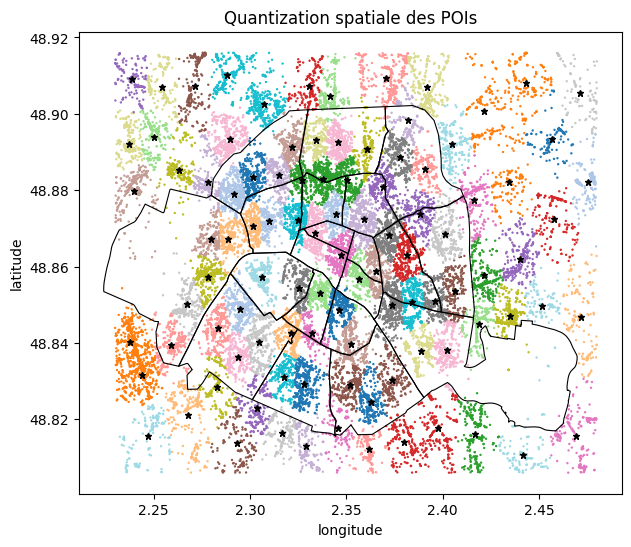


Taille des régions spatiales :
min = 111
max = 576
moyenne = 318.52

Clustering des régions spatiales selon les types
K retenu : 6
Inertie : 0.9412

Types dominants des clusters de régions :
cluster 0 : restaurant (0.365), bar (0.191), lodging (0.166)
cluster 1 : restaurant (0.249), lodging (0.177), bar (0.172)
cluster 2 : clothing_store (0.439), restaurant (0.200), home_goods_store (0.140)
cluster 3 : restaurant (0.292), clothing_store (0.222), bar (0.150)
cluster 4 : restaurant (0.400), bar (0.155), home_goods_store (0.152)
cluster 5 : home_goods_store (0.246), restaurant (0.235), clothing_store (0.194)


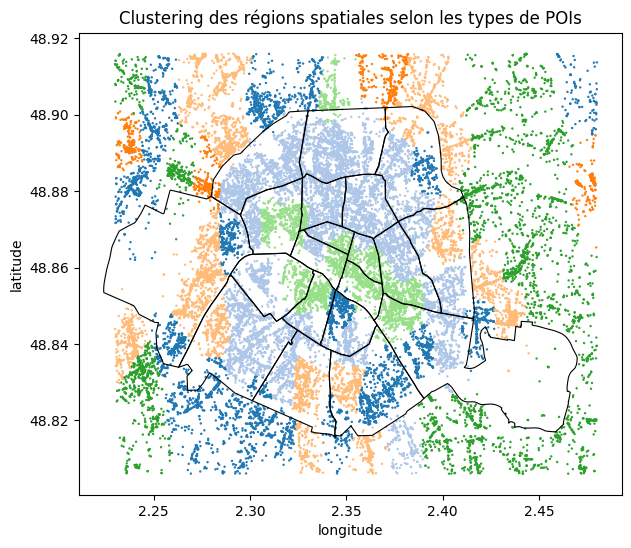

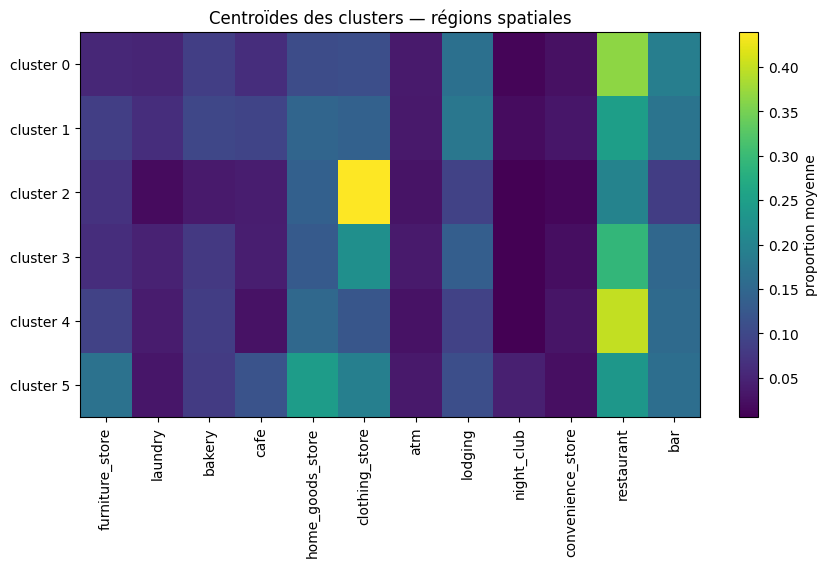

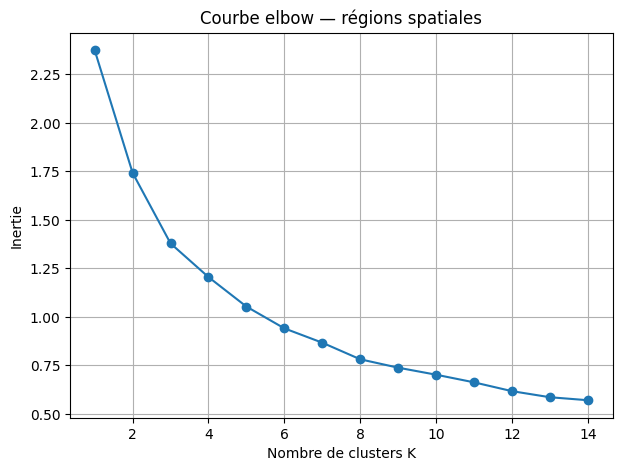


Valeurs de l'inertie pour les régions spatiales :
K= 1 | inertie=2.3746
K= 2 | inertie=1.7423
K= 3 | inertie=1.3790
K= 4 | inertie=1.2055
K= 5 | inertie=1.0535
K= 6 | inertie=0.9412
K= 7 | inertie=0.8674
K= 8 | inertie=0.7819
K= 9 | inertie=0.7386
K=10 | inertie=0.7025
K=11 | inertie=0.6631
K=12 | inertie=0.6177
K=13 | inertie=0.5864
K=14 | inertie=0.5710

Interprétation : le coude n'est pas parfaitement net, mais K=5 ou K=6 semble raisonnable.


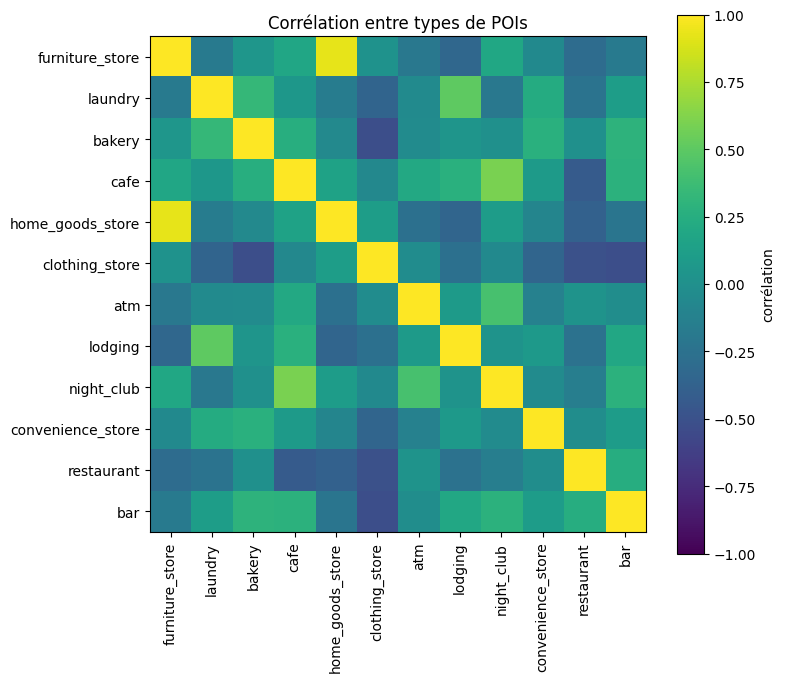


Corrélations les plus fortes en valeur absolue :
furniture_store / home_goods_store : 0.926
cafe / night_club : 0.595
clothing_store / bar : -0.522
bakery / clothing_store : -0.521
clothing_store / restaurant : -0.506
laundry / lodging : 0.501
cafe / restaurant : -0.428
atm / night_club : 0.416


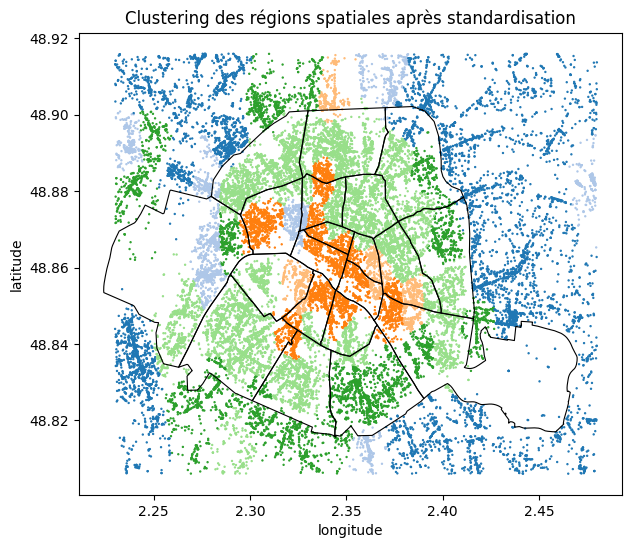


Standardisation
Inertie avant standardisation : 0.9412
Inertie après standardisation : 631.9848
Remarque : les inerties ne sont pas directement comparables car les échelles ont changé.


In [ ]:
# ============================================================
# Quantization spatiale et clustering des régions
# ============================================================


# 1. Quantization spatiale des POIs


K_GEO = 100      # équivalent à une grille 10 x 10
K_REGIONS = 6   # nombre de clusters de régions selon les types

coords = table_poi[["longitude", "latitude"]].values

km_spatial = KMeans(n_clusters=K_GEO, random_state=0, n_init=10)
labels_spatial = km_spatial.fit_predict(coords)

def get_cluster_spatial(i):
    """Renvoie le cluster spatial du i-ème POI."""
    return labels_spatial[i]

print("Nombre de régions spatiales :", K_GEO)
print("Inertie spatiale :", round(km_spatial.inertia_, 6))

# Visualisation des clusters spatiaux
plt.figure(figsize=(7, 6))
draw_districts()

plt.scatter(
    table_poi["longitude"],
    table_poi["latitude"],
    color=[tab20.colors[get_cluster_spatial(i) % 20] for i in range(len(table_poi))],
    s=0.5
)

for i in range(K_GEO):
    plt.plot(
        km_spatial.cluster_centers_[i, 0],
        km_spatial.cluster_centers_[i, 1],
        marker="*",
        color="black",
        markersize=5
    )

plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("Quantization spatiale des POIs")
plt.show()


# 2. Description des régions spatiales par les types de POIs


region_desc = np.zeros((K_GEO, len(types)))
region_counts = np.zeros(K_GEO)

for p in range(len(table_poi)):
    k = labels_spatial[p]
    region_desc[k] += table_poi.iloc[p][types].astype(float).values
    region_counts[k] += 1

for k in range(K_GEO):
    if region_counts[k] > 0:
        region_desc[k] /= region_counts[k]

print("\nTaille des régions spatiales :")
print("min =", int(region_counts.min()))
print("max =", int(region_counts.max()))
print("moyenne =", round(region_counts.mean(), 2))


# 3. Clustering des régions spatiales selon leur composition


km_regions = KMeans(n_clusters=K_REGIONS, random_state=0, n_init=10)
labels_regions = km_regions.fit_predict(region_desc)

print("\nClustering des régions spatiales selon les types")
print("K retenu :", K_REGIONS)
print("Inertie :", round(km_regions.inertia_, 4))

print("\nTypes dominants des clusters de régions :")
for k, center in enumerate(km_regions.cluster_centers_):
    order = np.argsort(center)[::-1][:3]
    top = ", ".join([f"{types[i]} ({center[i]:.3f})" for i in order])
    print(f"cluster {k} : {top}")

# Visualisation du clustering des régions selon les types
plt.figure(figsize=(7, 6))
draw_districts()

colors_regions = [
    tab20.colors[labels_regions[labels_spatial[i]] % 20]
    for i in range(len(table_poi))
]

plt.scatter(
    table_poi["longitude"],
    table_poi["latitude"],
    color=colors_regions,
    s=0.5
)

plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("Clustering des régions spatiales selon les types de POIs")
plt.show()

# Centroïdes des clusters de régions
plt.figure(figsize=(10, 5))
plt.imshow(km_regions.cluster_centers_, aspect="auto")
plt.colorbar(label="proportion moyenne")
plt.xticks(np.arange(len(types)), types, rotation=90)
plt.yticks(np.arange(K_REGIONS), [f"cluster {k}" for k in range(K_REGIONS)])
plt.title("Centroïdes des clusters — régions spatiales")
plt.show()


# 4. Courbe elbow sur les régions spatiales


K_values_regions = range(1, 15)
inertias_regions = []

for K in K_values_regions:
    km_tmp = KMeans(n_clusters=K, random_state=0, n_init=10)
    km_tmp.fit(region_desc)
    inertias_regions.append(km_tmp.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(K_values_regions), inertias_regions, marker="o")
plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertie")
plt.title("Courbe elbow — régions spatiales")
plt.grid()
plt.show()

print("\nValeurs de l'inertie pour les régions spatiales :")
for K, inertia in zip(K_values_regions, inertias_regions):
    print(f"K={K:2d} | inertie={inertia:.4f}")

print("\nInterprétation : le coude n'est pas parfaitement net, mais K=5 ou K=6 semble raisonnable.")


# 5. Corrélation entre types de POIs


corr_df = pd.DataFrame(region_desc, columns=types).corr()

plt.figure(figsize=(8, 7))
plt.imshow(corr_df, vmin=-1, vmax=1)
plt.colorbar(label="corrélation")
plt.xticks(np.arange(len(types)), types, rotation=90)
plt.yticks(np.arange(len(types)), types)
plt.title("Corrélation entre types de POIs")
plt.show()

corr_pairs = []
for i in range(len(types)):
    for j in range(i + 1, len(types)):
        corr_pairs.append((types[i], types[j], corr_df.iloc[i, j]))

corr_pairs = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)

print("\nCorrélations les plus fortes en valeur absolue :")
for a, b, c in corr_pairs[:8]:
    print(f"{a} / {b} : {c:.3f}")


# 6. Traitement possible : standardisation


# Sans standardisation, les types les plus fréquents dominent la distance euclidienne.
# On standardise donc les variables pour donner plus de poids aux types rares.

scaler = StandardScaler()
region_desc_std = scaler.fit_transform(region_desc)

km_std = KMeans(n_clusters=K_REGIONS, random_state=0, n_init=10)
labels_regions_std = km_std.fit_predict(region_desc_std)

plt.figure(figsize=(7, 6))
draw_districts()

colors_std = [
    tab20.colors[labels_regions_std[labels_spatial[i]] % 20]
    for i in range(len(table_poi))
]

plt.scatter(
    table_poi["longitude"],
    table_poi["latitude"],
    color=colors_std,
    s=0.5
)

plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("Clustering des régions spatiales après standardisation")
plt.show()

print("\nStandardisation")
print("Inertie avant standardisation :", round(km_regions.inertia_, 4))
print("Inertie après standardisation :", round(km_std.inertia_, 4))
print("Remarque : les inerties ne sont pas directement comparables car les échelles ont changé.")

